# 01 — Competitor Pricing Analysis

## Objective
Map the competitive pricing landscape for sleepwear and loungewear brands across UK and US markets. Identify price tiers, demographic coverage patterns, and any structural gaps in the market.

## Brands Analysed

### UK Brands
| Brand | Positioning | Primary Demographic |
|---|---|---|
| SHEIN | Ultra-budget | Kids (8–12) |
| George (Asda) | Budget | Kids (1–14) |
| Primark | Budget | Kids (5–15) |
| H&M Kids | Mass market | Kids (8–14) |
| Matalan | Mass market | Kids (4–13) |
| M&S | Mass market | Kids & teens (1–16) |
| Next | Mass market | Kids & teens (3–16) |
| Zara Kids | Mid-market | Kids (6–14) |
| River Island Kids | Mid-market | Kids (5–14) |
| Asos (own brand) | Mid-market | Adult (20–55) |
| Brandy Melville | Lifestyle / teen | Young adult (14–30) |
| Lounge | Lifestyle / DTC | Adult (20–55) |
| Boden | Premium casual | Kids (2–12) + adult |
| White Fox | Streetwear-adjacent | Young adult (16–30) |
| Desmond & Dempsey | Luxury | Adult (25–45) + kids (0–10) |

### US Brands
US brands included as reference points — to test whether premium teen sleepwear pricing is validated in a comparable market.

| Brand | Positioning | Primary Demographic |
|---|---|---|
| Pink Chicken | Premium | Kids (0–12) + adult |
| Katie J NYC | Premium | Kids/teen (4–16) |
| Roller Rabbit | Luxury | Adult + kids (0–12) |
| Eberjey | Luxury | Adult + kids |

## Methodology
Pricing data represents a curated sample of 3–5 representative products per brand, selected to map tier positioning rather than full catalogue depth. All data manually collected from public product pages, February–March 2026. USD prices converted to GBP at 0.79.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import os
from pathlib import Path
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
COLOURS = {'uk': '#2E5FA3', 'us': '#E8A838', 'gap': '#C0392B', 'neutral': '#7F8C8D'}
USD_GBP = 0.79

# Resolve notebook directory using relative path
DATA_DIR = Path('data')

print(f'Ready. Analysis date: {datetime.today().strftime("%d %B %Y")}')
print(f'USD/GBP rate: {USD_GBP}')

Ready. Analysis date: 13 March 2026
USD/GBP rate: 0.79


---
## Section 1: Price Dataset — All Brands

In [3]:
CSV_PATH = DATA_DIR / 'competitor_prices_all.csv'
assert CSV_PATH.exists(), f'File not found: {CSV_PATH}'

df_all = pd.read_csv(CSV_PATH)

print(f'Dataset: {len(df_all)} products across {df_all["brand"].nunique()} brands')
print(f'Markets: {df_all["market"].unique().tolist()}')
print()
df_all.groupby(['brand', 'market'])['price_gbp'].agg(['min', 'max', 'mean', 'count']).round(2)

Dataset: 61 products across 19 brands
Markets: ['UK', 'US']



,,min,max,mean,count
brand,market,,,,
Asos (own brand),UK,14.00,20.00,17.33,3
Boden,UK,32.00,75.00,47.67,3
Brandy Melville,UK,18.00,30.00,24.00,2
Desmond & Dempsey,UK,89.00,145.00,118.00,3
Eberjey,US,75.05,130.35,102.70,2
George (Asda),UK,9.00,20.00,12.80,5
H&M Kids,UK,7.99,19.99,14.19,5
Katie J NYC,US,61.62,75.05,68.33,2
Lounge,UK,40.00,40.00,40.00,2


---
## Section 2: UK vs US Price Ranges

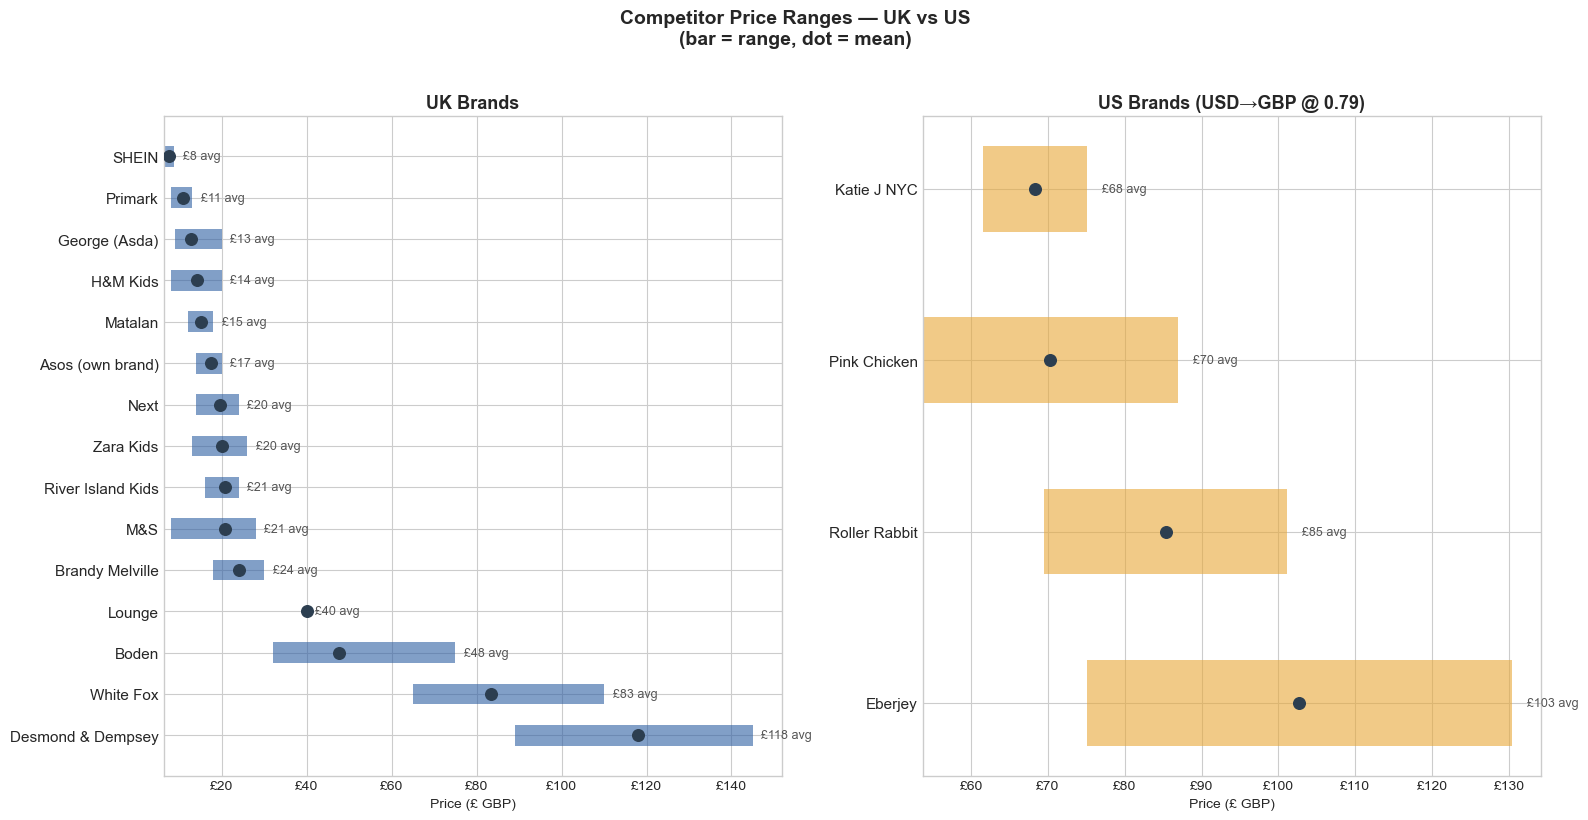

In [4]:
brand_summary = df_all.groupby(['brand', 'market'])['price_gbp'].agg(
    min_price='min', max_price='max', mean_price='mean'
).round(2).reset_index().sort_values(['market', 'mean_price'], ascending=[True, False])

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

for ax, market in zip(axes, ['UK', 'US']):
    data = brand_summary[brand_summary['market'] == market].reset_index(drop=True)
    colour = COLOURS['uk'] if market == 'UK' else COLOURS['us']

    for i, row in data.iterrows():
        ax.barh(i, row['max_price'] - row['min_price'],
                left=row['min_price'], height=0.5, color=colour, alpha=0.6)
        ax.scatter(row['mean_price'], i, color='#2C3E50', zorder=5, s=70)
        ax.text(row['max_price'] + 2, i, f"£{row['mean_price']:.0f} avg",
                va='center', fontsize=9, color='#555')

    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data['brand'].tolist(), fontsize=11)
    ax.set_xlabel('Price (£ GBP)', fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('£%d'))
    title = f'{market} Brands' if market == 'UK' else 'US Brands (USD→GBP @ 0.79)'
    ax.set_title(title, fontsize=13, fontweight='bold')

fig.suptitle('Competitor Price Ranges — UK vs US\n(bar = range, dot = mean)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Chart Commentary — UK vs US Price Ranges

**UK market** is split into two clear tiers with almost nothing in between. The mass-market cluster (SHEIN, George, Primark, H&M, Matalan, M&S, Next) sits between £6–28. Boden sits just above at £32–36. Then there is a large gap before Desmond & Dempsey (£89 for kids), which is positioned as a luxury gift product rather than a brand teenagers would buy for themselves.

**US market** tells a different story: Katie J NYC (£62–75) and Pink Chicken (£54–87) occupy a genuine mid-premium space aimed at kids and teens — a segment that has no UK equivalent. Roller Rabbit and Eberjey operate at luxury adult price points with kid lines attached.

**Key implication:** The UK market has a structural pricing gap between ~£36 and £89 in kids/teen nightwear. US brands validate that demand exists at £55–75 for this demographic in a comparable market.

---
## Section 3: Age Coverage Map

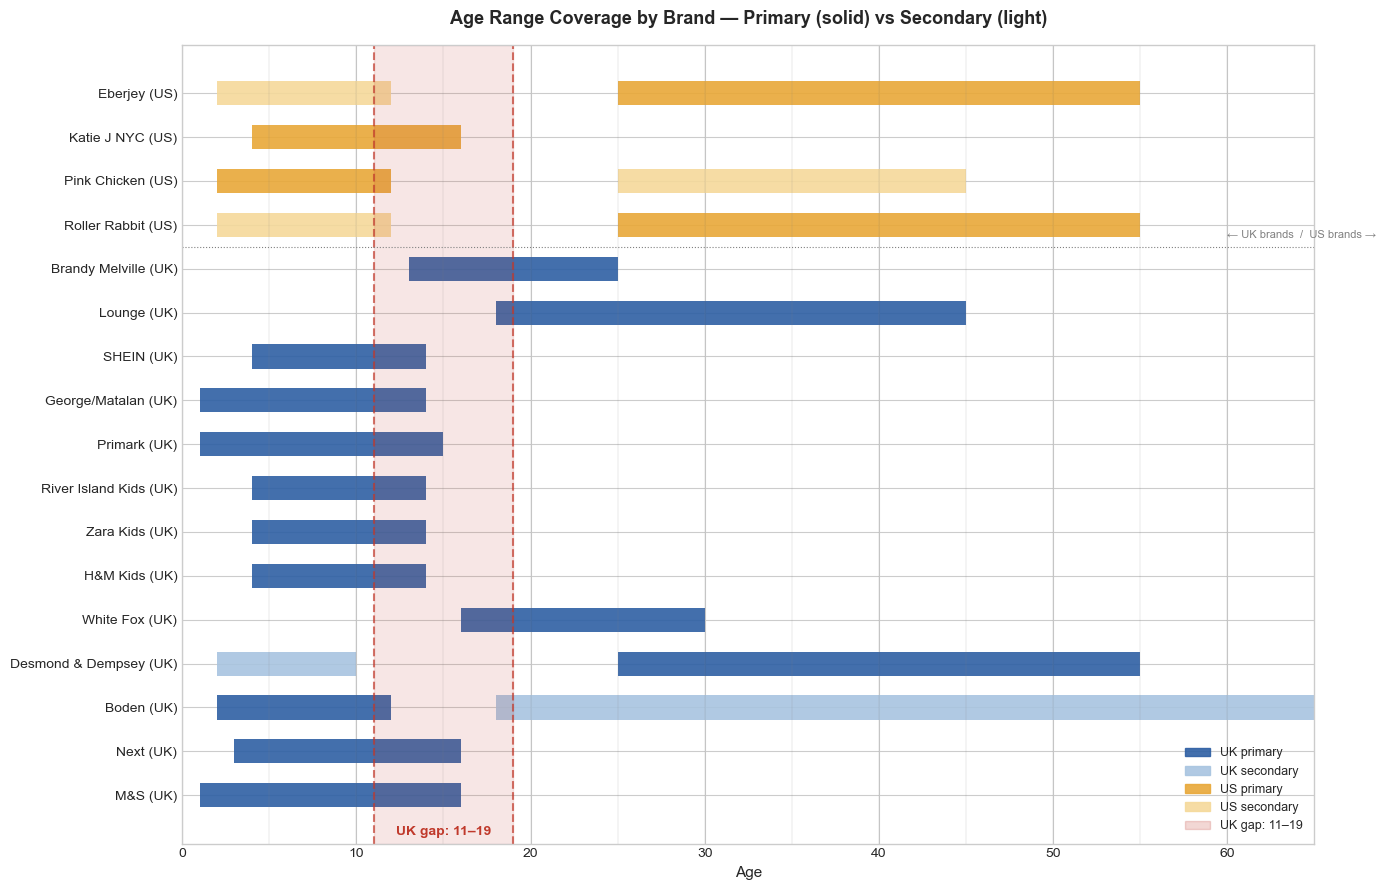

In [5]:
# Age ranges based on brand website sizing and product availability (Feb/Mar 2026).
# 'primary' = core target demographic; 'secondary' = extension line (e.g. kids line from adult brand).
# Brandy Melville: one-size model skews young; culturally teen-adjacent from ~14 upward.

coverage = {
    'M&S (UK)':                [(1, 16, 'UK', 'primary')],
    'Next (UK)':               [(3, 16, 'UK', 'primary')],
    'Boden (UK)':              [(2, 12, 'UK', 'primary'), (18, 65, 'UK', 'secondary')],
    'Desmond & Dempsey (UK)':  [(25, 55, 'UK', 'primary'), (2, 10, 'UK', 'secondary')],
    'White Fox (UK)':          [(16, 30, 'UK', 'primary')],
    'H&M Kids (UK)':           [(4, 14, 'UK', 'primary')],
    'Zara Kids (UK)':          [(4, 14, 'UK', 'primary')],
    'River Island Kids (UK)':  [(4, 14, 'UK', 'primary')],
    'Primark (UK)':            [(1, 15, 'UK', 'primary')],
    'George/Matalan (UK)':     [(1, 14, 'UK', 'primary')],
    'SHEIN (UK)':              [(4, 14, 'UK', 'primary')],
    'Lounge (UK)':             [(18, 45, 'UK', 'primary')],
    'Brandy Melville (UK)':    [(13, 25, 'UK', 'primary')],
    'Roller Rabbit (US)':      [(25, 55, 'US', 'primary'), (2, 12, 'US', 'secondary')],
    'Pink Chicken (US)':       [(2, 12, 'US', 'primary'), (25, 45, 'US', 'secondary')],
    'Katie J NYC (US)':        [(4, 16, 'US', 'primary')],
    'Eberjey (US)':            [(25, 55, 'US', 'primary'), (2, 12, 'US', 'secondary')],
}

colour_map = {
    ('UK', 'primary'): '#2E5FA3', ('UK', 'secondary'): '#A8C4E0',
    ('US', 'primary'): '#E8A838', ('US', 'secondary'): '#F5D99A',
}

brand_list = list(coverage.keys())
uk_count = sum(1 for b in brand_list if '(UK)' in b)

fig, ax = plt.subplots(figsize=(14, 9))

for i, brand in enumerate(brand_list):
    for (min_a, max_a, market, focus) in coverage[brand]:
        ax.barh(i, max_a - min_a, left=min_a, height=0.55,
                color=colour_map[(market, focus)], alpha=0.9)

# Gap shading
ax.axvspan(11, 19, alpha=0.12, color=COLOURS['gap'])
ax.axvline(11, color=COLOURS['gap'], lw=1.5, ls='--', alpha=0.7)
ax.axvline(19, color=COLOURS['gap'], lw=1.5, ls='--', alpha=0.7)
ax.text(15, -0.9, 'UK gap: 11–19', color=COLOURS['gap'], fontsize=10, fontweight='bold', ha='center')

# Divider UK / US
ax.axhline(uk_count - 0.5, color='grey', lw=0.8, ls=':')
ax.text(60, uk_count - 0.3, '← UK brands  /  US brands →', color='grey', fontsize=8)

for age in range(0, 65, 5):
    ax.axvline(age, color='grey', lw=0.3, alpha=0.4)

ax.set_yticks(range(len(brand_list)))
ax.set_yticklabels(brand_list, fontsize=10)
ax.set_xlabel('Age', fontsize=11)
ax.set_xlim(0, 65)
ax.set_title('Age Range Coverage by Brand — Primary (solid) vs Secondary (light)',
             fontsize=13, fontweight='bold', pad=15)

legend_elements = [
    mpatches.Patch(color='#2E5FA3', alpha=0.9, label='UK primary'),
    mpatches.Patch(color='#A8C4E0', alpha=0.9, label='UK secondary'),
    mpatches.Patch(color='#E8A838', alpha=0.9, label='US primary'),
    mpatches.Patch(color='#F5D99A', alpha=0.9, label='US secondary'),
    mpatches.Patch(color=COLOURS['gap'], alpha=0.2, label='UK gap: 11–19'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

### Chart Commentary — Age Coverage Map

The age coverage map reveals a consistent pattern across UK brands: **coverage effectively ends at age 14**. M&S and Next extend to 16, but their product offering at that age is functionally identical to what they sell to a 6-year-old — there is no distinct identity or aesthetic shift for the older teen.

**The 11–19 gap (shaded red)** is not simply a sizing gap — it is an identity gap. Brands serving this age group either:
- Are extensions of adult brands (White Fox, Lounge, Brandy Melville) that don't cater below 14–16
- Are mass-market kids brands (M&S, Next) that lose relevance as teens develop a stronger sense of style

**Desmond & Dempsey kids** only goes to age 10, making it a parent-purchase gift product, not something a teenager would choose themselves.

**US comparison:** Katie J NYC is the only brand in the dataset with a dedicated teen-facing product line extending to age 16 — and it has no UK equivalent. This reinforces the gap as a structural market feature rather than a deliberate choice by incumbents.

---
## Section 4: The UK Price Cliff

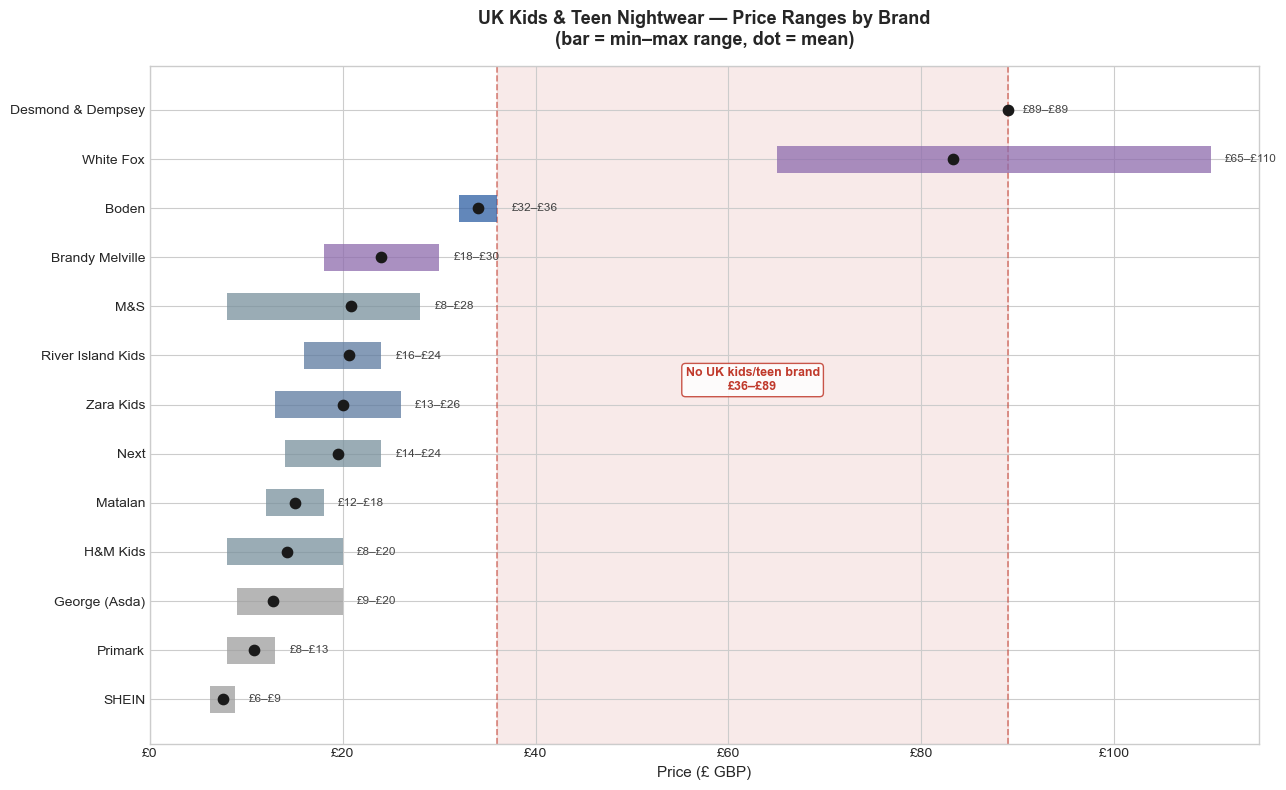

In [9]:
uk_kids = df_all[
    (df_all['market'] == 'UK') &
    (df_all['demographic'].isin(['Kids', 'Kids/Teen', 'Teen', 'Young Adult']))
].copy()

# Summarise to one row per brand: min, max, mean price
brand_sum = (
    uk_kids.groupby('brand')['price_gbp']
    .agg(min_p='min', max_p='max', mean_p='mean')
    .reset_index()
    .sort_values('mean_p')
    .reset_index(drop=True)
)

# Assign segment colours
SEGMENT = {
    'SHEIN':              '#9E9E9E',
    'George (Asda)':      '#9E9E9E',
    'Primark':            '#9E9E9E',
    'H&M Kids':           '#78909C',
    'Matalan':            '#78909C',
    'M&S':                '#78909C',
    'Next':               '#78909C',
    'Zara Kids':          '#5C7A9F',
    'River Island Kids':  '#5C7A9F',
    'Boden':              '#2E5FA3',
    'Brandy Melville':    '#8E6BAD',
    'White Fox':          '#8E6BAD',
    'Lounge':             '#8E6BAD',
    'Desmond & Dempsey':  '#C0392B',
}
default_colour = '#7F8C8D'

fig, ax = plt.subplots(figsize=(13, 8))

GAP_LO, GAP_HI = 36, 89   # the price cliff boundaries

# Shade the gap
ax.axvspan(GAP_LO, GAP_HI, alpha=0.10, color='#C0392B', zorder=0)
ax.axvline(GAP_LO, color='#C0392B', lw=1.2, ls='--', alpha=0.6, zorder=1)
ax.axvline(GAP_HI, color='#C0392B', lw=1.2, ls='--', alpha=0.6, zorder=1)

for i, row in brand_sum.iterrows():
    colour = SEGMENT.get(row['brand'], default_colour)
    bar_lo = row['min_p']
    bar_hi = row['max_p']
    # Range bar
    ax.barh(i, bar_hi - bar_lo, left=bar_lo, height=0.55,
            color=colour, alpha=0.75, zorder=2)
    # Mean dot
    ax.scatter(row['mean_p'], i, color='#1a1a1a', s=55, zorder=4)
    # Price label at right end
    ax.text(bar_hi + 1.5, i, f"£{row['min_p']:.0f}–£{bar_hi:.0f}",
            va='center', fontsize=8.5, color='#444')

# Gap annotation — positioned at mid-height to avoid title overlap
mid_gap = (GAP_LO + GAP_HI) / 2
mid_y = len(brand_sum) / 2
ax.text(mid_gap, mid_y,
        f'No UK kids/teen brand\n£{GAP_LO}–£{GAP_HI}',
        ha='center', va='center', fontsize=9, fontweight='bold',
        color='#C0392B',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#C0392B', alpha=0.85))

ax.set_yticks(range(len(brand_sum)))
ax.set_yticklabels(brand_sum['brand'].tolist(), fontsize=10)
ax.set_xlabel('Price (£ GBP)', fontsize=11)
ax.set_xlim(0, 115)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('£%d'))
ax.set_title('UK Kids & Teen Nightwear — Price Ranges by Brand\n(bar = min–max range, dot = mean)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

### Chart Commentary — The UK Price Cliff

With all UK brands now included — mass market, mid-market, lifestyle, and luxury — the pricing landscape reveals three distinct clusters and one conspicuous void.

**Mass market cluster (£6–28):** SHEIN, George, Primark, H&M, Matalan, M&S, Next, Zara Kids, and River Island Kids all sit here. These brands compete primarily on price and availability. None has a distinct teen identity or aesthetic — they are functional, not aspirational.

**Lifestyle / young adult brands (£18–£110):** Brandy Melville, Lounge, and White Fox operate above the mass-market ceiling but target adults or older teens (16+). Their price ranges partially overlap the shaded gap, but none specifically serves the 11–16 teen demographic with sleepwear. White Fox in particular (£65–£110) demonstrates that consumers will pay premium prices for identity-led loungewear — just not in a teen-specific format.

**Boden (£32–36):** The ceiling of the kids-focused accessible range. Strong visual identity and good quality, but targeted at younger kids (2–12) and parent-driven purchasing. Does not address the teen consumer directly.

**The gap (£36–£89):** No UK brand occupies this space for kids or teens specifically. The shaded zone sits empty of any brand with dedicated teen positioning — over £50 of pricing white space.

**Desmond & Dempsey Kids (£89):** A luxury price point, stops at age 10, and purchased as a gift. Not a competitor to a teen-facing brand — it occupies a completely different purchase occasion.

**What this chart shows:** The gap is not just about price — it is about identity. Brands that serve teens (Brandy Melville, White Fox) do so through adult lines that happen to fit younger bodies, not through dedicated teen-facing product or marketing. The structural opportunity is a brand that combines the identity-led approach of the lifestyle tier with the age-specific focus of the kids tier.

---
## Section 5: Key Findings

In [10]:
uk = df_all[df_all['market'] == 'UK']
us = df_all[df_all['market'] == 'US']

uk_all_segments = uk[uk['demographic'].isin(['Kids', 'Kids/Teen', 'Teen', 'Young Adult'])]
uk_kids_only = uk[uk['demographic'].isin(['Kids', 'Kids/Teen', 'Teen'])]

print('COMPETITOR PRICING ANALYSIS — KEY METRICS')
print('=' * 55)
print(f'Total products sampled:  {len(df_all)}')
print(f'Brands covered:          {df_all["brand"].nunique()} ({uk["brand"].nunique()} UK, {us["brand"].nunique()} US)')
print()
print(f'UK kids/teen price range: £{uk_kids_only["price_gbp"].min():.0f} – £{uk_kids_only["price_gbp"].max():.0f}')
print(f'UK mass market ceiling:   ~£{uk_kids_only[uk_kids_only["brand"].isin(["M&S", "Next", "Matalan"])]["price_gbp"].max():.0f}')
print(f'UK lifestyle/young adult: £{uk_all_segments[uk_all_segments["brand"].isin(["Brandy Melville", "White Fox", "Lounge"])]["price_gbp"].min():.0f} – £{uk_all_segments[uk_all_segments["brand"].isin(["Brandy Melville", "White Fox", "Lounge"])]["price_gbp"].max():.0f} (adult-facing, no teen sleepwear)')
print(f'UK premium floor (D&D):   £{uk[uk["brand"]=="Desmond & Dempsey"]["price_gbp"].min():.0f}')
print(f'Gap:                      £36 – £89 (no UK teen-focused brand)')
print()
print(f'US teen reference (Katie J NYC): £{us[us["brand"]=="Katie J NYC"]["price_gbp"].min():.0f} – £{us[us["brand"]=="Katie J NYC"]["price_gbp"].max():.0f}')
print('=' * 55)

COMPETITOR PRICING ANALYSIS — KEY METRICS
Total products sampled:  61
Brands covered:          19 (15 UK, 4 US)

UK kids/teen price range: £6 – £89
UK mass market ceiling:   ~£28
UK lifestyle/young adult: £18 – £110 (adult-facing, no teen sleepwear)
UK premium floor (D&D):   £89
Gap:                      £36 – £89 (no UK teen-focused brand)

US teen reference (Katie J NYC): £62 – £75


### Summary

1. **Three-tier UK market.** The pricing landscape splits into a mass-market cluster (£6–28), a lifestyle/young adult tier (Brandy Melville, Lounge, White Fox at £18–110), and a single luxury outlier (Desmond & Dempsey at £89+). The lifestyle brands serve older teens and adults but none offers dedicated teen sleepwear.

2. **Age coverage drops off at 14.** Most UK brands stop at age 12–14 for kids ranges. M&S and Next extend to 16 but with no aesthetic differentiation for teens. Lifestyle brands start at 14–16 but target upward, not downward. No UK brand specifically targets the 11–19 demographic with a distinct identity.

3. **US comparables validate higher price points.** Katie J NYC and Pink Chicken price at £54–75 GBP for kids/teens — demonstrating that demand exists at a premium above UK mass-market pricing.

4. **The gap is both pricing and identity.** The £36–£89 white space is not just about price — it reflects an absence of brands combining genuine aesthetic differentiation with teen-specific positioning. Lifestyle brands prove consumers pay for identity; kids brands prove the demographic buys sleepwear. No brand currently does both.

---

### Future Enhancements
- **Automated pricing collection:** M&S, Next, and other mass-market sites use client-side rendering (JavaScript). A Selenium or Playwright-based scraper would enable full catalogue price audits and ongoing monitoring.
- **Expanded sample depth:** Increasing from 3–5 to 10–15 products per brand would strengthen range analysis, particularly for brands with wide price distributions.